In [35]:
import numpy as np
import pandas as pd
from scipy.stats import boxcox
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

from warnings import filterwarnings;filterwarnings("ignore")

In [22]:
df = pd.read_csv("../data/omni2_1963.dat", header=None, sep="\s+")
df.columns = [
    'Year',              # 1: Год
    'Decimal Day',       # 2: День года (1 января = 1)
    'Hour',              # 3: Час UT (0-23)
    'Bartels',           # 4: Номер бартельсовского оборота
    'IMF_s/c_ID',        # 5: ID КА для ММП
    'Plasma_s/c_ID',     # 6: ID КА для плазмы
    'N_IMF_points',      # 7: Кол-во точек в среднем ММП
    'N_Plasma_points',   # 8: Кол-во точек в среднем плазмы
    'B_Magnitude_Avg',   # 9: Средняя напряженность поля |B| (nT)
    'B_Vector_Mag',      # 10: Модуль среднего вектора поля (nT)
    'B_Lat_GSE',         # 11: Широта угла ср. вектора поля (GSE)
    'B_Long_GSE',        # 12: Долгота угла ср. вектора поля (GSE)
    'Bx_GSE',            # 13: Bx GSE/GSM (nT)
    'By_GSE',            # 14: By GSE (nT)
    'Bz_GSE',            # 15: Bz GSE (nT)
    'By_GSM',            # 16: By GSM (nT)
    'Bz_GSM',            # 17: Bz GSM (nT) — **ВАЖНО: ключевой параметр**
    'sigma_B_Mag',       # 18: RMS отклонение |B|
    'sigma_B_Vector',    # 19: RMS отклонение вектора B
    'sigma_Bx',          # 20: RMS отклонение Bx
    'sigma_By',          # 21: RMS отклонение By
    'sigma_Bz',          # 22: RMS отклонение Bz
    'T_proton',          # 23: Температура протонов (K)
    'Np_density',        # 24: Плотность протонов (N/см³)
    'V_plasma',          # 25: Скорость плазмы (км/с) — **ВАЖНО**
    'V_Long_GSE',        # 26: Долгота потока плазмы (квази-GSE)
    'V_Lat_GSE',         # 27: Широта потока плазмы (GSE)
    'Na/Np',             # 28: Отношение альфа/протоны
    'P_dyn',             # 29: Динамическое давление (nPa)
    'sigma_T',           # 30: RMS отклонение T
    'sigma_N',           # 31: RMS отклонение N
    'sigma_V',           # 32: RMS отклонение V
    'sigma_phi_V',       # 33: RMS отклонение phi V
    'sigma_theta_V',     # 34: RMS отклонение theta V
    'sigma_Na/Np',       # 35: RMS отклонение Na/Np
    'E_field',           # 36: Электрическое поле (мВ/м)
    'Plasma_beta',       # 37: Плазма бета
    'Alfven_Mach',       # 38: Число Альфвена Маха
    'Kp',                # 39: **ЦЕЛЕВАЯ ПЕРЕМЕННАЯ** (индекс Kp)
    'R_sunspot',         # 40: Число солнечных пятен
    'Dst',               # 41: **ЦЕЛЕВАЯ ПЕРЕМЕННАЯ** (Dst индекс, nT)
    'AE',                # 42: **ЦЕЛЕВАЯ ПЕРЕМЕННАЯ** (AE индекс, nT)
    'P_flux_>1MeV',      # 43: Поток протонов >1 МэВ
    'P_flux_>2MeV',      # 44: Поток протонов >2 МэВ
    'P_flux_>4MeV',      # 45: Поток протонов >4 МэВ
    'P_flux_>10MeV',     # 46: Поток протонов >10 МэВ
    'P_flux_>30MeV',     # 47: Поток протонов >30 МэВ
    'P_flux_>60MeV',     # 48: Поток протонов >60 МэВ
    'Flag',              # 49: Флаг качества данных
    'ap',                # 50: ap-индекс (nT)
    'f10.7',             # 51: Индекс F10.7 (солнечное радиоизлучение)
    'PC(N)',             # 52: PC(N) индекс
    'AL',                # 53: AL-индекс (nT)
    'AU',                # 54: AU-индекс (nT)
    'Mach_num'           # 55: Магнитозвуковое число Маха
]
df.head()

,Year,Decimal Day,Hour,Bartels,IMF_s/c_ID,Plasma_s/c_ID,N_IMF_points,N_Plasma_points,B_Magnitude_Avg,B_Vector_Mag,...,P_flux_>10MeV,P_flux_>30MeV,P_flux_>60MeV,Flag,ap,f10.7,PC(N),AL,AU,Mach_num
0,1963,1,0,1771,99,99,999,999,999.9,999.9,...,99999.99,99999.99,99999.99,0,3,999.9,999.9,99999,99999,99.9
1,1963,1,1,1771,99,99,999,999,999.9,999.9,...,99999.99,99999.99,99999.99,0,3,999.9,999.9,99999,99999,99.9
2,1963,1,2,1771,99,99,999,999,999.9,999.9,...,99999.99,99999.99,99999.99,0,3,999.9,999.9,99999,99999,99.9
3,1963,1,3,1771,99,99,999,999,999.9,999.9,...,99999.99,99999.99,99999.99,0,7,999.9,999.9,99999,99999,99.9
4,1963,1,4,1771,99,99,999,999,999.9,999.9,...,99999.99,99999.99,99999.99,0,7,999.9,999.9,99999,99999,99.9


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 55 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             8760 non-null   int64  
 1   Decimal Day      8760 non-null   int64  
 2   Hour             8760 non-null   int64  
 3   Bartels          8760 non-null   int64  
 4   IMF_s/c_ID       8760 non-null   int64  
 5   Plasma_s/c_ID    8760 non-null   int64  
 6   N_IMF_points     8760 non-null   int64  
 7   N_Plasma_points  8760 non-null   int64  
 8   B_Magnitude_Avg  8760 non-null   float64
 9   B_Vector_Mag     8760 non-null   float64
 10  B_Lat_GSE        8760 non-null   float64
 11  B_Long_GSE       8760 non-null   float64
 12  Bx_GSE           8760 non-null   float64
 13  By_GSE           8760 non-null   float64
 14  Bz_GSE           8760 non-null   float64
 15  By_GSM           8760 non-null   float64
 16  Bz_GSM           8760 non-null   float64
 17  sigma_B_Mag      8760 non

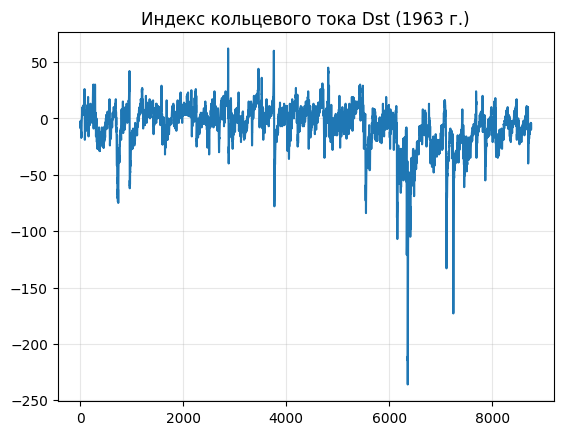

In [ ]:
plt.plot(df["Dst"])
plt.title("Индекс кольцевого тока Dst (1963 г.)")
plt.xlabel()
plt.grid(alpha=0.3)
plt.show()

5.1277220636504195


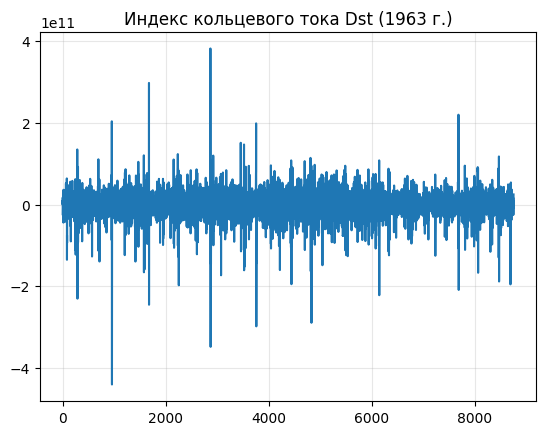

In [49]:
data = df["Dst"].to_numpy().copy()
data = data - 1.1 * data.min()
data, lmbda = boxcox(data)
print(lmbda)
data = np.diff(data)
plt.plot(data)
plt.title("Индекс кольцевого тока Dst (1963 г.)")
plt.grid(alpha=0.3)
plt.show()